In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [27]:
# Data Requirements \ Preprocessing

train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train size: {train_size}, Validation size: {val_size}, Test size: {len(test_dataset)}")

Train size: 48000, Validation size: 12000, Test size: 10000


In [26]:
# Model Requirements

class MLP(nn.Module):
    def __init__(self, hidden_neurons, activation_fn):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()


        self.hidden = nn.Linear(28 * 28, hidden_neurons)
        self.bn = nn.BatchNorm1d(hidden_neurons)
        self.activation = activation_fn
        self.dropout = nn.Dropout(0.2)


        self.output = nn.Linear(hidden_neurons, 10)
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.bn(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.output(x)
        return x

In [25]:
#Training

def train_and_evaluate(model, optimizer, criterion, epochs=10):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
# Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

 # Validation
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = running_loss / len(val_loader)
        val_acc = 100 * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs


def test_model(model):
    model.eval()
    correct, total = 0, 0
    test_loss = 0.0
    all_preds, all_labels = [], []
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    final_loss = test_loss / len(test_loader)

In [28]:
#Experimentation Requirements

criterion = nn.CrossEntropyLoss()

print("\n Starting Experiment 1 (ReLU, 128 Neurons, LR=0.001)")
model_exp1 = MLP(hidden_neurons=128, activation_fn=nn.ReLU()).to(device)
optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=0.001)
exp1_train_loss, exp1_val_loss, exp1_train_acc, exp1_val_acc = train_and_evaluate(model_exp1, optimizer_exp1, criterion)

print("\n Starting Experiment 2 (Sigmoid, 64 Neurons, LR=0.01)")
model_exp2 = MLP(hidden_neurons=64, activation_fn=nn.Sigmoid()).to(device)
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=0.01)
exp2_train_loss, exp2_val_loss, exp2_train_acc, exp2_val_acc = train_and_evaluate(model_exp2, optimizer_exp2, criterion)


 Starting Experiment 1 (ReLU, 128 Neurons, LR=0.001)
Epoch [1/10] - Train Loss: 0.3726, Train Acc: 89.99% | Val Loss: 0.1937, Val Acc: 94.48%
Epoch [2/10] - Train Loss: 0.2101, Train Acc: 93.83% | Val Loss: 0.1439, Val Acc: 95.89%
Epoch [3/10] - Train Loss: 0.1728, Train Acc: 94.90% | Val Loss: 0.1180, Val Acc: 96.45%
Epoch [4/10] - Train Loss: 0.1488, Train Acc: 95.47% | Val Loss: 0.1093, Val Acc: 96.79%
Epoch [5/10] - Train Loss: 0.1347, Train Acc: 95.85% | Val Loss: 0.0978, Val Acc: 97.05%
Epoch [6/10] - Train Loss: 0.1238, Train Acc: 96.23% | Val Loss: 0.0963, Val Acc: 97.01%
Epoch [7/10] - Train Loss: 0.1196, Train Acc: 96.28% | Val Loss: 0.0942, Val Acc: 97.31%
Epoch [8/10] - Train Loss: 0.1135, Train Acc: 96.52% | Val Loss: 0.0841, Val Acc: 97.40%
Epoch [9/10] - Train Loss: 0.1028, Train Acc: 96.87% | Val Loss: 0.0863, Val Acc: 97.20%
Epoch [10/10] - Train Loss: 0.1033, Train Acc: 96.78% | Val Loss: 0.0831, Val Acc: 97.42%

 Starting Experiment 2 (Sigmoid, 64 Neurons, LR=0.01)


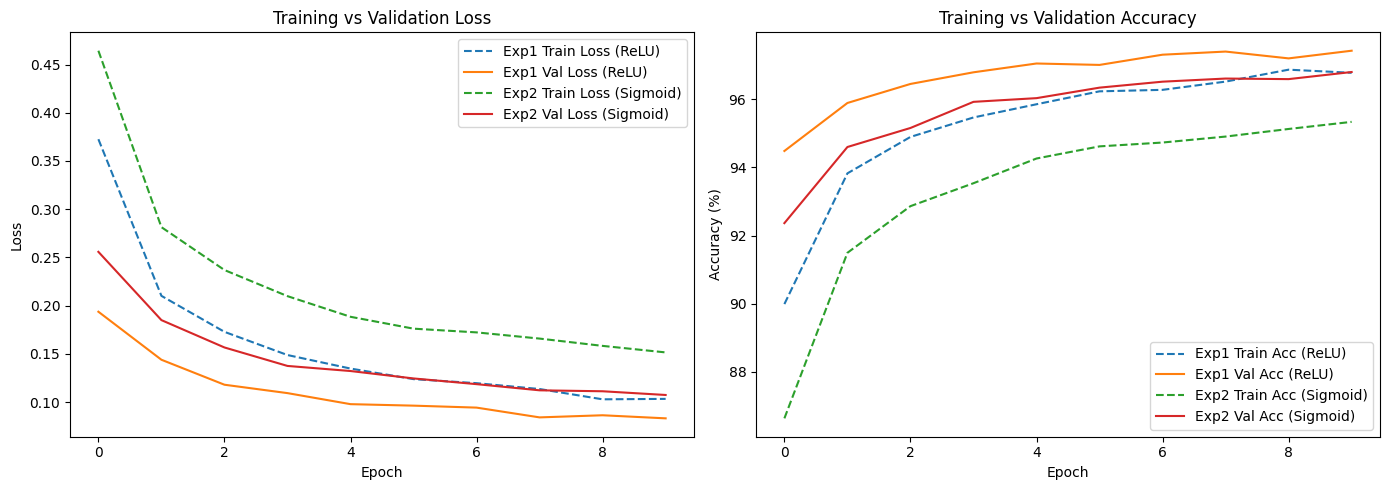

In [29]:
#Visualization Requirements
plt.figure(figsize=(14, 5))

# Plotting Loss Curves
plt.subplot(1, 2, 1)
plt.plot(exp1_train_loss, label='Exp1 Train Loss (ReLU)', linestyle='--')
plt.plot(exp1_val_loss, label='Exp1 Val Loss (ReLU)')
plt.plot(exp2_train_loss, label='Exp2 Train Loss (Sigmoid)', linestyle='--')
plt.plot(exp2_val_loss, label='Exp2 Val Loss (Sigmoid)')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(exp1_train_acc, label='Exp1 Train Acc (ReLU)', linestyle='--')
plt.plot(exp1_val_acc, label='Exp1 Val Acc (ReLU)')
plt.plot(exp2_train_acc, label='Exp2 Train Acc (Sigmoid)', linestyle='--')
plt.plot(exp2_val_acc, label='Exp2 Val Acc (Sigmoid)')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()